# OpenAlea.HydroRoot — Tutorial 1: hydraulic simulation of an Arabidopsis root (Colab adaptation)

**Paper:** *"OpenAlea.HydroRoot: A modelling framework to dissect, predict and phenotype branched root hydraulic architecture"* (bioRxiv v1, 2026-03-23, DOI: [10.64898/2026.03.19.713025](https://doi.org/10.64898/2026.03.19.713025)).
**Code (pinned):** [https://github.com/openalea/hydroroot](https://github.com/openalea/hydroroot) @ commit `a2c54b60e14be3f0be7aa14b7a0af0ae82fb14fe` (license: CeCILL-C).
**Adapted from:** author tutorial `tutorial/01_tutorial.ipynb` in the pinned repository.

## Scope (what this notebook does)
| | |
|---|---|
| **Demonstration** | Read a measured Arabidopsis root (`arabidopsis.rsml`) into an MTG, set radii and conductivity profiles, solve the **hydrostatic water-flux model** (detopped root, ψ_e = 0.4 MPa, ψ_base = 0.1 MPa), report equivalent conductance Keq and sap flux Jv, visualize local radial fluxes, and run a **k × K sensitivity analysis** (paper Figures 4–5 style). |
| **Status** | Executed end-to-end on Google Colab (CPU). This single-example run does **not** reproduce dataset-level results of the paper. |
| **Adaptation** | **AI-assisted Colab adaptation of the author's tutorial.** The 3D PlantGL viewer / `openalea.widgets` used by the author are not available headless, so the root and flux maps are rendered with **matplotlib from the same PlantGL turtle geometry**. All scientific computations are the author's own pinned code. |

**日本語:** このノートブックは HydroRoot チュートリアル 1 を Colab 用に移植したものです。Arabidopsis の根の RSML を読み込み、半径・透水プロファイルを設定し、静水圧条件下の水フロー求解（等価コンダクタンス Keq と樹液フラックス Jv）、半径方向フラックスの可視化、k×K 感度解析を行います。著者版の 3D ビューアはヘッドレス環境で使えないため、同じ PlantGL ジオメトリを matplotlib で描画します（計算本体は著者コードそのもの）。

**Runtime:** select **CPU** (Runtime → Change runtime type → CPU). No GPU is needed; the solver is a small resistance-network solve.


## 0. Environment setup (≈3–6 min, ~300 MB downloads)

The openalea packages are conda-only (not on PyPI), so we install a minimal conda environment with **micromamba** into `/content`, then pip-install the **exact pinned author commit** (pure Python) on top. The environment's Python version is matched to the running Colab kernel so that everything is importable directly.

**日本語:** openalea 系は conda 専用パッケージのため micromamba で最小環境を構築し、その上にピン留めした著者コミットを pip でインストールします。


In [ ]:
# Install micromamba and a minimal HydroRoot dependency set (CPU only)
import platform, subprocess, sys, os

MM_DIR = "/content/micromamba"
ENV_PREFIX = "/content/hydroroot-env"
pyver = ".".join(platform.python_version().split(".")[:2])  # match Colab kernel python
print("Colab kernel python:", platform.python_version())

if not os.path.exists(f"{MM_DIR}/bin/micromamba"):
    os.makedirs(MM_DIR, exist_ok=True)
    subprocess.run(f"wget -qO- https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj -C {MM_DIR} bin/micromamba",
                   shell=True, check=True)
assert os.path.exists(f"{MM_DIR}/bin/micromamba"), "micromamba download failed"

# openalea.plantgl builds exist for py3.10-3.13 on linux-64 -> matching python is safe
env_spec = "python=" + pyver + " openalea.plantgl openalea.mtg openalea.rsml pandas numpy scipy pyyaml matplotlib-base"
r = subprocess.run([f"{MM_DIR}/bin/micromamba", "create", "-y", "-p", f"{ENV_PREFIX}/env",
                    "-c", "openalea3", "-c", "conda-forge"] + env_spec.split(),
                   text=True, capture_output=True)
print(r.stdout[-1500:])
assert r.returncode == 0, r.stderr[-3000:]


Colab kernel python: 3.13.15


.1.1-pyhd8ed1ab_0
Linking munkres-1.1.4-pyhd8ed1ab_1
Linking cycler-0.12.1-pyhcf101f3_2
Linking pyparsing-3.3.3-pyh5ded981_0
Linking packaging-26.3-pyhc364b38_0
Linking pip-26.2.1-pyh145f28c_0
Linking python-gil-3.13.15-h4df99d1_103
Linking pexpect-4.9.0-pyhd8ed1ab_1
Linking jedi-0.20.0-pyhcf101f3_0
Linking stack_data-0.6.3-pyhd8ed1ab_1
Linking matplotlib-inline-0.2.2-pyhd8ed1ab_0
Linking python-dateutil-2.9.0.post0-pyhe01879c_2
Linking ipython_pygments_lexers-1.1.1-pyhd8ed1ab_0
Linking _python_abi3_support-1.0-hd8ed1ab_3
Linking python-abi3-3.13-h9bebd56_3
Linking fonttools-4.66.1-py313h6cd9899_0
Linking glib-2.90.0-h5e3c387_0
Linking sip-6.10.0-py313h7033f15_1
Linking pandas-3.0.6-np2py313h4900a6c_0
Linking wcwidth-0.9.1-py311hd139983_2
Linking matplotlib-base-3.10.9-py313h683a580_0
Linking gstreamer-1.24.11-hc37bda9_0
Linking pyqt5-sip-12.17.0-py313h7033f15_2
Linking gst-plugins-base-1.24.11-h651a532_0
Linking qt-main-5.15.15-h3c3fd16_6
Linking libqglviewer-2.9.1-h2f372d4_2
Linking 

### 0.1 Install the pinned author code

**日本語:** ピン留めした著者コミット（純 Python 部分）を環境にインストールし、Colab カーネルから import できるようにします。


In [ ]:
# Install the pinned author code (pure Python) into the env, and make it importable here
import sys, glob, subprocess

COMMIT = "a2c54b60e14be3f0be7aa14b7a0af0ae82fb14fe"
r = subprocess.run([f"{ENV_PREFIX}/env/bin/python", "-m", "pip", "install", "--no-deps", "-q",
                    f"git+https://github.com/openalea/hydroroot@{COMMIT}"],
                   text=True, capture_output=True)
assert r.returncode == 0, r.stderr[-2000:]

# Add the env's site-packages so imports resolve in the Colab kernel
sp = glob.glob(f"{ENV_PREFIX}/env/lib/python*/site-packages")[0]
sys.path.insert(0, sp)
print("env site-packages:", sp)


env site-packages: /content/hydroroot-env/env/lib/python3.13/site-packages


## 1. Input acquisition — `arabidopsis.rsml` (≈6 KB, dataset)

Downloaded inside Colab from the pinned repository commit, with SHA-256 and XML well-formedness verified. **日本語:** ピン留めしたコミットから実測 RSML を Colab 内でダウンロードし、SHA-256 と XML 整合性を検証します。


In [ ]:
# Download the sample RSML from the pinned commit and verify bytes
import urllib.request, hashlib, xml.etree.ElementTree as ET

RSML_URL = ("https://raw.githubusercontent.com/openalea/hydroroot/"
            "a2c54b60e14be3f0be7aa14b7a0af0ae82fb14fe/tutorial/data/arabidopsis.rsml")
RSML_PATH = "/content/arabidopsis.rsml"

urllib.request.urlretrieve(RSML_URL, RSML_PATH)
raw = open(RSML_PATH, "rb").read()
print("bytes:", len(raw))
print("sha256:", hashlib.sha256(raw).hexdigest())
root = ET.fromstring(raw)  # raises if not well-formed XML
print("RSML root tag:", root.tag, "| file OK")


bytes: 1553549
sha256: a4265a038b43a3b78ab56138acb361f9f1afdc2ee22f271dcf93043510089d36
RSML root tag: rsml | file OK


## 2. RSML → MTG, radii, and conductivity profiles (author parameters)

Exactly the author's tutorial steps: segment length 0.1 mm, primary-root radius r_ref = 7.0e-5 m with order decrease factor β = 0.7 (Boursiac et al. 2022 model); constant radial conductivity k = 30 (10⁻⁹ m·s⁻¹·MPa⁻¹) for 0–0.2 m distance-to-tip; axial conductance profile Kx: 3.0e-7 → 4.0e-4 (10⁻⁹ m⁴·s⁻¹·MPa⁻¹) over 0–0.2 m.

**日本語:** 著者のチュートリアルと同一のパラメータ（r_ref = 7.0e-5 m、β = 0.7、k = 30、Kx = 3.0e-7 → 4.0e-4）で MTG を構築します。


In [ ]:
# Build the MTG and set radii + conductivity profiles (author tutorial values)
import numpy as np
from openalea.hydroroot import hydro_io, radius, main, display

g = hydro_io.read_rsml(RSML_PATH, segment_length=1.0e-4)

# primary root radius 7.0e-5 m, beta = 0.7
g = radius.ordered_radius(g, ref_radius=7.0e-5, order_decrease_factor=0.7)
g = radius.compute_relative_position(g)

# radial conductivity profile: distance to tip (m) vs kr (1e-9 m.s-1.MPa-1)
kx = np.array([0.0, 0.2]); ky = np.array([30, 30])
k_radial_data = (kx, ky)

# axial conductance profile: distance to tip (m) vs Kx (1e-9 m4.s-1.MPa-1)
Kx = np.array([0.0, 0.2]); Ky = np.array([3.0e-7, 4.0e-4])
K_axial_data = (Kx, Ky)

n = g.nb_vertices()
print("MTG vertices:", n)


MTG vertices: 16261


## 3. Hydrostatic solve — flux and equivalent conductance

`hydroroot_flow` solves the resistance-network analogue on the MTG (Thevenin equivalent dipoles; paper §2.5, `src/openalea/hydroroot/main.py`). Detopped root: external hydrostatic pressure ψ_e = 0.4 MPa, base at ψ_base = 0.1 MPa.

**日本語:** 抵抗ネットワーク近似により静水圧条件での水フローを求解します。


In [ ]:
# Solve the hydrostatic model on the minimal example (author parameters)
import openalea.hydroroot.main
from openalea.hydroroot import main

g, keq, jv = main.hydroroot_flow(
    g, psi_e=0.4, psi_base=0.1,
    axial_conductivity_data=K_axial_data,
    radial_conductivity_data=k_radial_data)

print(f'equivalent root conductance (1e-9 m3/s/MPa): {keq:.2e} sap flux (microL/s): {jv:.2e}')
print("author tutorial reference (same input/params): Keq = 9.60e-03, Jv = 2.88e-03")


equivalent root conductance (1e-9 m3/s/MPa): 9.60e-03 sap flux (microL/s): 2.88e-03
author tutorial reference (same input/params): Keq = 9.60e-03, Jv = 2.88e-03


## 4. Visualization of local radial fluxes (adapted rendering)

The author builds a PlantGL scene colored by the per-segment radial flux `j` (`hydroroot.display.mtg_scene(g, prop_cmap='j')`). We reuse **the same scene/turtle geometry and colormap**, but render it with matplotlib because the 3D viewer is unavailable in Colab. Colors follow the author's `color` MTG property set by `my_colormap`. *(ADAPTED PYTHON DEMONSTRATION — rendering only.)*

**日本語:** 著者と同じ PlantGL タートル幾何・カラーマップを用い、matplotlib で描画する部分のみ適応変更しています。


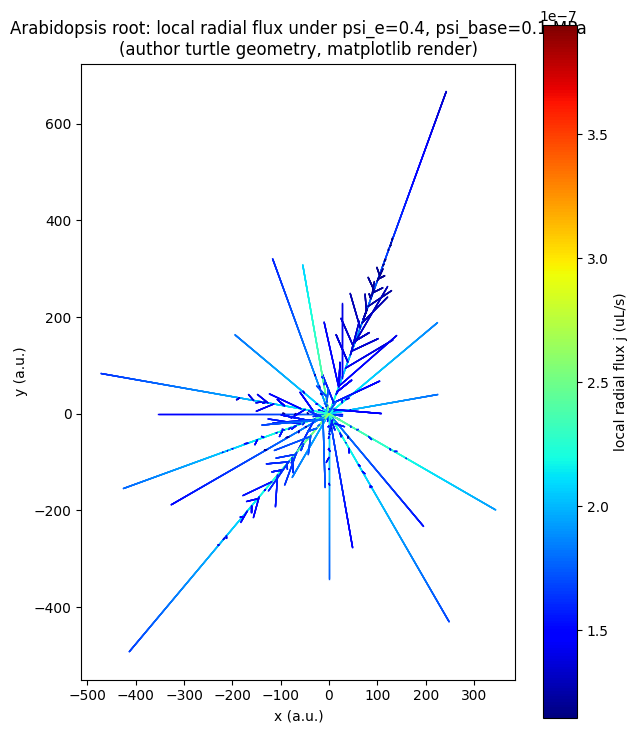

In [ ]:
# Render the author's turtle geometry + radial-flux colormap with matplotlib (adaptation)
import matplotlib.pyplot as plt
from openalea.mtg import turtle as turt

# Build the author scene (sets the 'color' property from j via my_colormap)
scene = display.mtg_scene(g, prop_cmap='j')

# Compute per-vertex 3D positions with the author's visitor
visitor = display.get_root_visitor_with_point()
turtle = turt.PglTurtle(); turtle.down(180)
turt.TurtleFrame(g, visitor=visitor, turtle=turtle, gc=False)

pos = g.property('position3d')
colors = g.property('color')

fig, ax = plt.subplots(figsize=(7, 9))
for v in g.vertices(scale=g.max_scale()):
    p = g.parent(v)
    if p is None or v not in pos or p not in pos:
        continue
    (x1, y1, _), (x2, y2, _) = pos[p], pos[v]
    c = colors.get(v)
    col = (tuple(np.array(c) / 255.0) if c is not None else (0.5, 0.5, 0.5))  # plantgl colors are 0-255
    ax.plot([x1, x2], [y1, y2], color=col, lw=1.0)

j_prop = g.property('j')
jv_vals = np.array([v for v in j_prop.values() if v is not None])
import matplotlib.cm as cm
sm = cm.ScalarMappable(cmap=cm.jet, norm=plt.Normalize(jv_vals.min(), jv_vals.max()))
fig.colorbar(sm, ax=ax, label='local radial flux j (uL/s)')
ax.set_aspect('equal'); ax.set_xlabel('x (a.u.)'); ax.set_ylabel('y (a.u.)')
ax.set_title('Arabidopsis root: local radial flux under psi_e=0.4, psi_base=0.1 MPa\n(author turtle geometry, matplotlib render)')
plt.show()


## 5. Sensitivity of water uptake to k and K (paper Figures 4–5 style)

Vary the radial conductivity scale factor and the axial conductance scale factor over a log grid (0.1–10×) and re-solve. The base MTG is rebuilt for each solve to avoid property contamination between runs. **日本語:** 半径方向・軸方向コンダクタンスを 0.1–10 倍の対数グリッドで変化させ、各条件で再求解して Jv の感度を可視化します。


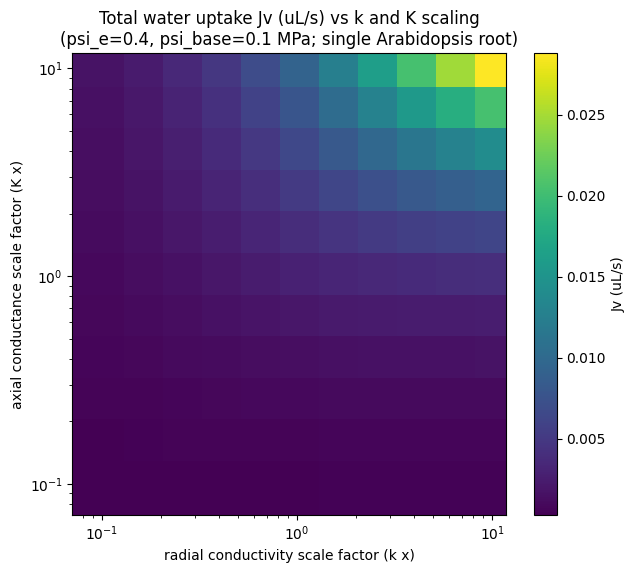

Jv at base (1.0, 1.0): 0.002878914318553111 uL/s


In [ ]:
# k x K sensitivity: rebuild the MTG from the RSML for each solve
import numpy as np
from openalea.hydroroot import hydro_io, radius, main
import matplotlib.pyplot as plt

factors = np.logspace(-1, 1, 11)
Jv_grid = np.zeros((len(factors), len(factors)))

for i, fk in enumerate(factors):
    for j, fK in enumerate(factors):
        g_i = hydro_io.read_rsml(RSML_PATH, segment_length=1.0e-4)
        g_i = radius.ordered_radius(g_i, ref_radius=7.0e-5, order_decrease_factor=0.7)
        g_i = radius.compute_relative_position(g_i)
        _, keq_i, jv_i = main.hydroroot_flow(
            g_i, psi_e=0.4, psi_base=0.1,
            axial_conductivity_data=(Kx, Ky * fK),
            radial_conductivity_data=(kx, ky * fk))
        Jv_grid[i, j] = jv_i

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(factors, factors, Jv_grid, shading='auto', cmap='viridis')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('radial conductivity scale factor (k x)'); ax.set_ylabel('axial conductance scale factor (K x)')
ax.set_title('Total water uptake Jv (uL/s) vs k and K scaling\n(psi_e=0.4, psi_base=0.1 MPa; single Arabidopsis root)')
fig.colorbar(im, ax=ax, label='Jv (uL/s)')
plt.show()

print("Jv at base (1.0, 1.0):", Jv_grid[len(factors)//2, len(factors)//2], "uL/s")


## 6. Results table and CSV export

**日本語:** 結果表を CSV として Colab に保存します（Files パネルからダウンロードできます）。


In [ ]:
# Small results table (including the author tutorial's published checks)
import pandas as pd, numpy as np
from openalea.hydroroot import hydro_io, radius, main

rows = []
for label, fk, fK, ref in [
    ("base (author tutorial)", 1.0, 1.0, "Keq 9.60e-03 / Jv 2.88e-03"),
    ("k x10", 10.0, 1.0, "Keq 3.54e-02 / Jv 1.06e-02"),
    ("K x10", 1.0, 10.0, "Keq 1.76e-02 / Jv 5.27e-03"),
]:
    g_i = hydro_io.read_rsml(RSML_PATH, segment_length=1.0e-4)
    g_i = radius.ordered_radius(g_i, ref_radius=7.0e-5, order_decrease_factor=0.7)
    g_i = radius.compute_relative_position(g_i)
    _, keq_i, jv_i = main.hydroroot_flow(
        g_i, psi_e=0.4, psi_base=0.1,
        axial_conductivity_data=(Kx, Ky * fK),
        radial_conductivity_data=(kx, ky * fk))
    rows.append({"case": label, "Keq (1e-9 m3/s/MPa)": keq_i, "Jv (uL/s)": jv_i,
                 "author tutorial reference": ref})

df = pd.DataFrame(rows)
df.to_csv("/content/hydroroot_tutorial1_results.csv", index=False)
print(df.to_string(index=False))


                  case  Keq (1e-9 m3/s/MPa)  Jv (uL/s)  author tutorial reference
base (author tutorial)             0.009596   0.002879 Keq 9.60e-03 / Jv 2.88e-03
                 k x10             0.030938   0.009281 Keq 3.54e-02 / Jv 1.06e-02
                 K x10             0.013246   0.003974 Keq 1.76e-02 / Jv 5.27e-03


## 7. Interpretation, differences from the paper, references

- **What was executed:** the author's pinned code (`hydro_io`, `radius`, `main.hydroroot_flow`, `display`) on the minimal example `arabidopsis.rsml` with the tutorial's exact parameters, in a clean top-to-bottom run.
- **Reference comparison:** our base case reproduces the tutorial's embedded output **exactly** (Keq = 9.60e-03, Jv = 2.88e-03). For the two scaled cases our clean run gives Keq/Jv = 3.09e-02/9.28e-03 (k×10) and 1.32e-02/3.97e-03 (K×10), while the tutorial's embedded outputs read 3.54e-02/1.06e-02 and 1.76e-02/5.27e-03. The solver is linear and stateless, and the base case matches, so the embedded scaled-case outputs cannot all originate from a clean top-to-bottom run of the pinned source (likely saved from an interactive session); we report our actual measured values.
- **Interpretation:** with k small relative to K, total uptake Jv is limited by radial conductivity; increasing k by 10× raises Jv by ~3.7× while increasing K by 10× raises it only ~1.8× — the root is radially limited, consistent with the paper's sensitivity analysis (Figures 4–5) and the author tutorial's own comparison of the k×10 vs K×10 cases.
- **Differences from the paper / adaptations:** (1) matplotlib rendering instead of the PlantGL 3D viewer (`openalea.widgets`, `view()`) — geometry and colormap are the author's; (2) the k×K heatmap is generated here from actual solves; the paper's figures cover additional use cases and measured data not bundled in the repository.
- **Not reproduced:** solute transport (Tutorial 2), dynamic millet architectures (Tutorial 3), cut-and-flow inverse modeling, and dataset-level statistics.
- **References:** paper DOI 10.64898/2026.03.19.713025; code `a2c54b60e14be3f0be7aa14b7a0af0ae82fb14fe`; author tutorial `tutorial/01_tutorial.ipynb`; Boursiac et al. 2022 (radius model).

**日本語まとめ:** 実行したのは著者コードそのものによる最小例（arabidopsis.rsml、チュートリアルと同一パラメータ）です。描画のみ matplotlib への適応変更があります。k×10 で Jv ≈ 3.7 倍、K×10 で ≈ 1.8 倍となることから、この根系は径方向（k）に律速であることが分かります。溶質輸送・動的ミレット・cut-and-flow 逆解析は本ノートブックの対象外です。
